# CNN ENTRENAMIENTO

### Callback de Accuracy (Keras)

In [17]:
from dataclasses import dataclass

@dataclass
class MetricsValue:
    value: float
    value_name: str

@dataclass
class MetricsDto:
    name: str
    step: int
    step_type: str
    phase: str
    values: list[MetricsValue]

In [ ]:
import tensorflow as tf
import json
import paho.mqtt.client as mqtt
import csv
import os
from datetime import datetime
from dataclasses import asdict

folder = "AccuracyFiles"
os.makedirs(folder, exist_ok=True)

filename = folder + "/Accuracy_" + datetime.now().strftime("%Y%m%d") + ".csv"

class AccuracyCallback(tf.keras.callbacks.Callback):
    def __init__(self, epoch_offset=0):
        self.offset = epoch_offset
        try:
            self.mqtt_client = mqtt.Client()
            broker = "localhost"
            port = 1883
            self.mqtt_client.connect(broker, port)
            self.mqtt_client.loop_start()

        except Exception as e:
            print(f"Error conectando con el broker: {e}")
            self.mqtt = None

    def on_epoch_end(self, epoch, logs=None,  ):
        train_dto = MetricsDto(
            name= "CNN",
            step=epoch + self.offset,
            step_type="epoch",
            phase="train",
            values=[
                MetricsValue(value=float(logs.get("accuracy", 0.0)), value_name="accuracy"),
                MetricsValue(value=float(logs.get("loss", 0.0)), value_name="loss (scc)")
            ]
        )
        val_dto = MetricsDto(
        name= "CNN",
        step=epoch + self.offset,
        step_type="epoch",
        phase="val",
        values=[
            MetricsValue(value=float(logs.get("val_accuracy", 0.0)), value_name="accuracy"),
            MetricsValue(value=float(logs.get("val_loss", 0.0)), value_name="loss (scc)")
        ]
        )
        self.mqtt_client.publish("training/metrics", json.dumps(asdict(train_dto)), qos=1)
        self.mqtt_client.publish("training/metrics", json.dumps(asdict(val_dto)), qos=1)


    def save_data(self, data):
        with open(filename, "a", newline="") as file:
            writer = csv.writer(file)
            writer.writerow([datetime.now().strftime("%Y%m%d-%H%M"), data["epoch"], data["accuracy"]])




### 1. Resnet50 con Transfer Learning

Dataset: RealWaste

Idea: Probar transfer learning descongelando distinto número de capas y observar el trade-off entre Accuracy y consumo. Mantener constante el entrenamiento de la FC.

(Potencialmente podría mirar variando las epochs de entrenamiento de la FC)

1.1 Entrenamiento

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50 
from tensorflow.keras.applications.resnet50 import preprocess_input


layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

train_dataset = utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    class_names=None,
    subset="training",
    validation_split=0.2,
    batch_size=32,
    image_size=(224,224),
    shuffle=True,
    seed=12,
)

validation_dataset = utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    class_names=None,
    subset="validation",
    validation_split=0.2,
    batch_size=32,
    image_size=(224,224),
    shuffle=True,
    seed=12,
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
])

resnet_model = ResNet50(
    weights = "imagenet",
    include_top=False, # eliminar la capa final para adaptarlo al dataset y categorizar como corresponda 
    input_shape=(224,224,3)
)

resnet_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = resnet_model(x , training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(9, activation="softmax")(x) 
model = models.Model(inputs, outputs)

model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenar última capa
print("Starting training of FC layer")
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=5, callbacks=[AccuracyCallback()])

# Descongelar capas finales
resnet_model.trainable = True
for layer in resnet_model.layers[:-10]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Finetune
print("Starting finetuning training")
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=5, callbacks=[AccuracyCallback()])
    

# Evaluar CNN
test_loss, test_acc = model.evaluate(validation_dataset)
print("\nCNN - Test accuracy:", test_acc)


Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Starting training of FC layer
Epoch 1/5


C:\Users\pablo\AppData\Local\Temp\ipykernel_11200\3111150483.py:17: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


119/119 ━━━━━━━━━━━━━━━━━━━━ 121s 982ms/step - accuracy: 0.5668 - loss: 1.2330 - val_accuracy: 0.7000 - val_loss: 0.8266
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 114s 960ms/step - accuracy: 0.7491 - loss: 0.7128 - val_accuracy: 0.7495 - val_loss: 0.7093
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 115s 965ms/step - accuracy: 0.7898 - loss: 0.5876 - val_accuracy: 0.7674 - val_loss: 0.6693
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 115s 966ms/step - accuracy: 0.8151 - loss: 0.5274 - val_accuracy: 0.7937 - val_loss: 0.6158
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 115s 965ms/step - accuracy: 0.8296 - loss: 0.4588 - val_accuracy: 0.7874 - val_loss: 0.6277
Starting finetuning training
Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.8538 - loss: 0.4404 - val_accuracy: 0.7916 - val_loss: 0.6155
Epoch 2/5
 22/119 ━━━━━━━━━━━━━━━━━━━━ 1:25 882ms/step - accuracy: 0.8743 - loss: 0.3541

KeyboardInterrupt: 

1.2 Validación visual

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = validation_dataset.class_names

for images, labels in validation_dataset.take(1):  # coge un batch
    images = images.numpy()
    labels = labels.numpy()

idxs = np.random.choice(len(images), 5, replace=False)

for i in idxs:
    img = images[i].astype("uint8")
    label = labels[i]

    img_input = np.expand_dims(images[i], axis=0)
    pred = np.argmax(model.predict(img_input, verbose=0))

    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred]} | Real: {class_names[label]}")
    plt.axis("off")
    plt.show()

### 2. CNN propia

Dataset:

Idea: Probar una red convolucional utilizando diferente número de epochs y observando la relación entre el consumo y accuracy, tratando de determinar el final del periodo crítico y entender cuando deja de ser eficiente seguir entrenando. Posibilidad de quizás probar a reducir a partir de X punto (considerado el periodo crítico) la cantidad de recursos del entrenamiento para observar si la reducción de recursos impacta positivamente en el consumo sin producir un detrimento en el accuracy.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

train_dataset = utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    class_names=None,
    subset="training",
    validation_split=0.2,
    batch_size=32,
    image_size=(256,256),
    shuffle=True,
    seed=12,
)

validation_dataset = utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    class_names=None,
    subset="validation",
    validation_split=0.2,
    batch_size=32,
    image_size=(256,256),
    shuffle=True,
    seed=12,
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
])

class_names = train_dataset.class_names
num_classes = len(class_names)

# Normalizar a [0,1]
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

# Definir modelo CNN
inputs = tf.keras.Input(shape=(256,256,3))
x = data_augmentation(inputs)
x = layers.Conv2D(16, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenar CNN
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=8, batch_size=64)

# Evaluar CNN
test_loss, test_acc = model.evaluate(validation_dataset)
print("\nCNN - Test accuracy:", test_acc)

Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Epoch 1/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 219ms/step - accuracy: 0.2620 - loss: 2.0234 - val_accuracy: 0.3432 - val_loss: 1.9410
Epoch 2/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 210ms/step - accuracy: 0.3824 - loss: 1.6960 - val_accuracy: 0.5032 - val_loss: 1.4979
Epoch 3/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 210ms/step - accuracy: 0.4487 - loss: 1.5348 - val_accuracy: 0.4589 - val_loss: 1.6024
Epoch 4/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 209ms/step - accuracy: 0.5192 - loss: 1.3325 - val_accuracy: 0.5232 - val_loss: 1.4555
Epoch 5/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 210ms/step - accuracy: 0.5366 - loss: 1.3150 - val_accuracy: 0.5326 - val_loss: 1.4073
Epoch 6/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 208ms/step - accuracy: 0.5634 - loss: 1.2157 - val_accuracy: 0.5453 - val_loss: 1.3083
Epoch 7/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 208ms/step - accuracy: 0.5821 - 

: 

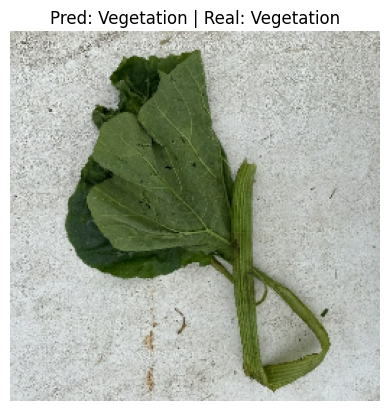

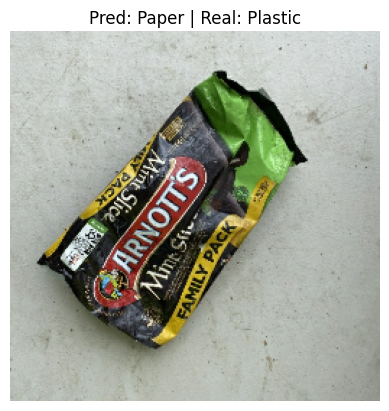

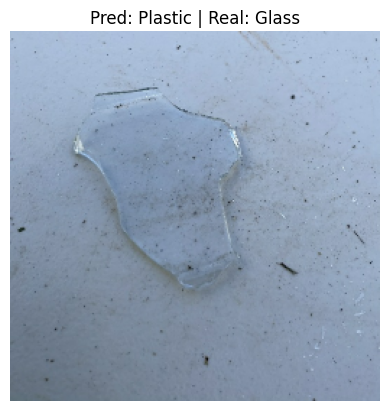

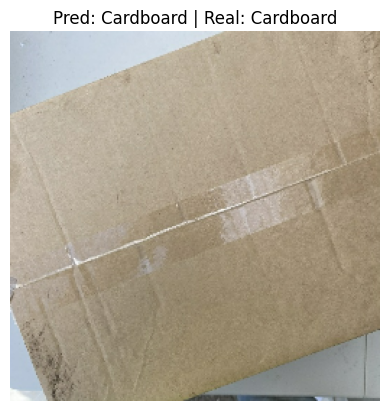

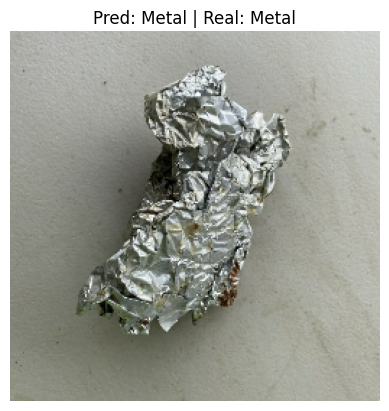

In [22]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in validation_dataset.take(1):  # coge un batch
    images = images.numpy()
    labels = labels.numpy()

idxs = np.random.choice(len(images), 5, replace=False)

for i in idxs:
    img = (images[i] * 255).astype("uint8")
    label = labels[i]

    img_input = np.expand_dims(images[i], axis=0)
    pred = np.argmax(model.predict(img_input, verbose=0))

    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred]} | Real: {class_names[label]}")
    plt.axis("off")
    plt.show()